In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PPO_SIL_pfolio_mps import MarketConfig, PPOSILConfig, train_ppo_sil, evaluate_policy, load_ppo_sil
from PPO_SIL_pfolio_mps_visuals import evaluate_policy, evaluate_single_path, plot_single_path_diagnostics, evaluate_and_plot_single_path, load_ppo_sil

In [2]:
log_returns_corr_matrix = pd.read_excel('/Users/goshabor/NTNU/10.Semester/TMA4900 – Industriell matematikk, masteroppgave/Code/Experiment 2 – Calibration/SMI/FFTResults/CalibrationResults/corr_matrix.xlsx')
log_returns_corr_matrix = log_returns_corr_matrix.to_numpy(dtype=float)

FFT_estimates = pd.read_excel('/Users/goshabor/NTNU/10.Semester/TMA4900 – Industriell matematikk, masteroppgave/Code/Experiment 2 – Calibration/SMI/FFTResults/CalibrationResults/FFT_estimates.xlsx')
FFT_estimates

,TKR,S0,r,mu,mu_uncapped,mu_Q,C,G,M,sigma,theta,nu
0,ABB,82.86,-0.0004,0.127094,0.184898,-0.012319,12.028845,12.968054,21.431640,0.294213,-0.366309,0.083134
1,ALCC,49.61,-0.0004,-0.083546,-0.083546,-0.006060,11.271924,14.032037,21.542191,0.273092,-0.280050,0.088716
2,CFR,156.55,-0.0004,0.000324,0.080265,-0.021527,106.265383,48.271206,48.273558,0.302004,-0.000107,0.009410
3,GALD,158.35,-0.0004,0.187403,0.246114,-0.004830,27.445113,17.934348,40.144548,0.276116,-0.846653,0.036436
4,GEBN,503.40,-0.0004,-0.006973,-0.006973,-0.026565,88.253821,58.969168,65.840212,0.213218,-0.156185,0.011331
5,GIVN,2683.00,-0.0004,-0.058919,-0.058919,-0.028390,2.618908,5.165600,15.376532,0.256794,-0.336672,0.381838
6,HOLN,76.26,-0.0004,0.133587,0.195023,-0.046450,20.039086,20.850715,30.237841,0.252126,-0.298359,0.049902
7,LONN,474.20,-0.0004,0.011345,0.011345,-0.013668,17.456671,17.845342,25.153005,0.278893,-0.284201,0.057285
8,NESN,76.88,-0.0004,-0.034524,-0.034524,-0.042247,12.186183,19.116281,37.332470,0.184801,-0.311054,0.082060
9,NOVN,116.80,-0.0004,0.061636,0.078652,-0.034462,54.732930,45.214604,57.048538,0.206005,-0.251105,0.018271


In [3]:
portfolio_weights_df = pd.read_excel('/Users/goshabor/NTNU/10.Semester/TMA4900 – Industriell matematikk, masteroppgave/Code/Experiment 2 – Calibration/SMI/FFTResults/CalibrationResults/pfolio_weights.xlsx')
portfolio_weights_df = portfolio_weights_df[portfolio_weights_df['TKR']!='Cash']
portfolio_weights_df['w'] = portfolio_weights_df['w']/100

df = pd.merge(FFT_estimates, portfolio_weights_df, on='TKR', how='outer')
df.loc[df['TKR']=='GALD', 'mu'] = df.loc[df['TKR']=='GALD', 'mu']*3/4
df.loc[df['TKR']=='SDZ', 'mu'] = df.loc[df['TKR']=='SDZ', 'mu']*5/6
df

,TKR,S0,r,mu,mu_uncapped,mu_Q,C,G,M,sigma,theta,nu,w,w_alt
0,ABB,82.86,-0.0004,0.127094,0.184898,-0.012319,12.028845,12.968054,21.431640,0.294213,-0.366309,0.083134,0.0758,15.00
1,ALCC,49.61,-0.0004,-0.083546,-0.083546,-0.006060,11.271924,14.032037,21.542191,0.273092,-0.280050,0.088716,0.0222,1.83
2,CFR,156.55,-0.0004,0.000324,0.080265,-0.021527,106.265383,48.271206,48.273558,0.302004,-0.000107,0.009410,0.0552,2.18
3,GALD,158.35,-0.0004,0.140553,0.246114,-0.004830,27.445113,17.934348,40.144548,0.276116,-0.846653,0.036436,0.0181,20.26
4,GEBN,503.40,-0.0004,-0.006973,-0.006973,-0.026565,88.253821,58.969168,65.840212,0.213218,-0.156185,0.011331,0.0132,0.99
5,GIVN,2683.00,-0.0004,-0.058919,-0.058919,-0.028390,2.618908,5.165600,15.376532,0.256794,-0.336672,0.381838,0.0188,0.00
6,HOLN,76.26,-0.0004,0.133587,0.195023,-0.046450,20.039086,20.850715,30.237841,0.252126,-0.298359,0.049902,0.0247,12.98
7,LONN,474.20,-0.0004,0.011345,0.011345,-0.013668,17.456671,17.845342,25.153005,0.278893,-0.284201,0.057285,0.0261,6.43
8,NESN,76.88,-0.0004,-0.034524,-0.034524,-0.042247,12.186183,19.116281,37.332470,0.184801,-0.311054,0.082060,0.1505,1.36
9,NOVN,116.80,-0.0004,0.061636,0.078652,-0.034462,54.732930,45.214604,57.048538,0.206005,-0.251105,0.018271,0.1712,1.28


In [4]:
d = len(df)
T = 1.0
n_steps = int(252)
r = 0.0

mu = df['mu'].astype(float).to_list()
s0 = df['S0'].astype(float).to_list()

# New preferred SSG inputs.
sigma = df['sigma'].astype(float).to_list()
theta = df['theta'].astype(float).to_list()
nu = df['nu'].astype(float).to_list()

pfolio_value = 50000
risky_portfolio_value = float(df['w'].sum())*pfolio_value
cash = pfolio_value - risky_portfolio_value

value_per_asset = risky_portfolio_value * df['w'].to_numpy(dtype=float)
h0 = (value_per_asset/np.asarray(s0, dtype=float)).tolist()

print(f'Initial cash: {cash}')
print(f'Initial holdings: {h0}')

Initial cash: 69.99999999999272
Initial holdings: [45.675766352884395, 22.343196936101595, 17.605467901628874, 5.707186611935587, 1.3092491060786655, 0.3498635855385762, 16.171924993443486, 2.7481505693800083, 97.74278095733612, 73.1850684931507, 0.7854538252602988, 26.197646875000004, 0.9499955752212391, 14.589935064935064, 6.2500944733112895, 5.278162468960626, 1.078955348615091, 12.539974884889075, 98.15063500828273, 5.6315364120781535]


In [5]:
N_eff_min = 4.545
max_name_weight = 1.0 / N_eff_min

s0_np = df["S0"].to_numpy(dtype=float)

min_pfolio_weights = [0.01]*d
h_min = np.round(np.asarray(min_pfolio_weights)*risky_portfolio_value/np.asarray(s0))

min_holding = h_min.tolist()
#max_holding = [100] * d #(max_name_weight*pfolio_value/s0_np).tolist()
max_holding = np.round(max_name_weight*pfolio_value/s0_np, decimals=0).astype(int).tolist()

print(min_holding)
print(h0)
print(max_holding)

[6.0, 10.0, 3.0, 3.0, 1.0, 0.0, 7.0, 1.0, 6.0, 4.0, 1.0, 2.0, 1.0, 7.0, 6.0, 4.0, 1.0, 4.0, 14.0, 1.0]
[45.675766352884395, 22.343196936101595, 17.605467901628874, 5.707186611935587, 1.3092491060786655, 0.3498635855385762, 16.171924993443486, 2.7481505693800083, 97.74278095733612, 73.1850684931507, 0.7854538252602988, 26.197646875000004, 0.9499955752212391, 14.589935064935064, 6.2500944733112895, 5.278162468960626, 1.078955348615091, 12.539974884889075, 98.15063500828273, 5.6315364120781535]
[133, 222, 70, 69, 22, 4, 144, 23, 143, 94, 12, 34, 16, 162, 130, 78, 13, 92, 304, 20]


In [6]:
for i in range(len(min_holding)):
    print(f'TKR: {df.iloc[i]['TKR']}, min: {min_holding[i]}, h0: {round(h0[i], 3)}, max: {max_holding[i]}')

TKR: ABB, min: 6.0, h0: 45.676, max: 133
TKR: ALCC, min: 10.0, h0: 22.343, max: 222
TKR: CFR, min: 3.0, h0: 17.605, max: 70
TKR: GALD, min: 3.0, h0: 5.707, max: 69
TKR: GEBN, min: 1.0, h0: 1.309, max: 22
TKR: GIVN, min: 0.0, h0: 0.35, max: 4
TKR: HOLN, min: 7.0, h0: 16.172, max: 144
TKR: LONN, min: 1.0, h0: 2.748, max: 23
TKR: NESN, min: 6.0, h0: 97.743, max: 143
TKR: NOVN, min: 4.0, h0: 73.185, max: 94
TKR: PGHN, min: 1.0, h0: 0.785, max: 12
TKR: ROPC, min: 2.0, h0: 26.198, max: 34
TKR: SCMN, min: 1.0, h0: 0.95, max: 16
TKR: SDZ, min: 7.0, h0: 14.59, max: 162
TKR: SGSN, min: 6.0, h0: 6.25, max: 130
TKR: SIKA, min: 4.0, h0: 5.278, max: 78
TKR: SLHN, min: 1.0, h0: 1.079, max: 13
TKR: SRENH, min: 4.0, h0: 12.54, max: 92
TKR: UBSG, min: 14.0, h0: 98.151, max: 304
TKR: ZURN, min: 1.0, h0: 5.632, max: 20


In [7]:
market = MarketConfig(
    d=d,
    T=T,
    n_steps=n_steps,
    r=r,
    mu=mu,
    s0=s0,
    h0=h0,
    cash0=cash,

    sigma=sigma,
    theta=theta,
    nu=nu,
    log_returns_corr_matrix=log_returns_corr_matrix,

    ssg_path_mean_samples=20,
    ssg_max_simulated_paths_per_chunk=4096,

    fixed_cost=1.5, #Interactive Brokers
    proportional_cost=5*1e-4,

    min_holding=min_holding,
    max_holding=max_holding,
    max_trade_size=[25.0] * d,
    self_financing=True,
    allow_negative_cash=False,

    randomize_initial_prices=False,
    randomize_initial_holdings=False,
    randomize_initial_cash=False,

    reward_scale=1e-3,
    min_price=1e-8,
    max_price=1e8,
)

ppo_cfg = PPOSILConfig(
    seed=42,
    device='mps',
    dtype='float32',

    train_iters=300,
    rollout_envs=1024,

    gamma_rl=1.0,
    gae_lambda=0.97,

    ppo_epochs=1, #3-4
    minibatch_size=1024,
    lr=2e-4,
    weight_decay=0.0,
    clip_eps=0.20,
    value_coef=0.50,
    entropy_coef=5e-1, #5e-2
    target_kl=0.05,
    max_grad_norm=1.0,

    hidden_dims=(512, 256, 128, 256, 512),
    activation='tanh',
    layer_norm=False,
    decision_bias=0.0,
    init_log_std=-0.35,

    use_sil=True,
    sil_buffer_capacity=500_000,
    sil_batch_size=4096,
    sil_updates_per_iter=1,
    sil_warmup_iters=100,
    keep_sil_on_cpu=True,

    eval_envs=1,
    eval_every=1000,
    eval_batch_size=256,
    eval_deterministic=True,
    log_every=1,
    checkpoint_path='PPO_SIL_pfolio_mps.pt',
    clear_cache=True,
)

result = train_ppo_sil(market, ppo_cfg)

[PPO-SIL iter 0001/300] d_pi=6.259e-05 u_pi=2.064e-02 d_v=3.853e-01 u_v=3.847e-01 ent_d=0.692 ent_u=21.783 kl=(1.30e-03,1.80e-02) train_discWT=50752.13 trades=52.23 eval_discWT=53247.95
[PPO-SIL iter 0002/300] d_pi=1.291e-03 u_pi=2.106e-02 d_v=3.737e-01 u_v=3.736e-01 ent_d=0.692 ent_u=22.575 kl=(1.46e-03,1.45e-02) train_discWT=50762.40 trades=51.25 eval_discWT=nan
[PPO-SIL iter 0003/300] d_pi=-1.605e-03 u_pi=1.755e-02 d_v=4.091e-01 u_v=4.096e-01 ent_d=0.693 ent_u=23.343 kl=(7.42e-04,1.51e-02) train_discWT=50820.06 trades=50.58 eval_discWT=nan
[PPO-SIL iter 0004/300] d_pi=9.532e-04 u_pi=1.433e-02 d_v=4.121e-01 u_v=4.130e-01 ent_d=0.693 ent_u=24.087 kl=(1.10e-03,1.25e-02) train_discWT=50906.63 trades=49.64 eval_discWT=nan
[PPO-SIL iter 0005/300] d_pi=1.092e-03 u_pi=1.466e-02 d_v=4.033e-01 u_v=4.034e-01 ent_d=0.693 ent_u=24.814 kl=(6.38e-04,1.38e-02) train_discWT=50998.93 trades=50.88 eval_discWT=nan
[PPO-SIL iter 0006/300] d_pi=-1.455e-04 u_pi=1.827e-02 d_v=3.721e-01 u_v=3.729e-01 ent_d=

In [8]:
eval_stats = evaluate_policy(
    result['agent'],
    result['env'],
    n_envs=2048,
    deterministic=False,
    batch_size=256,
)

eval_stats

{'terminal_wealth_mean': 55322.46875,
 'terminal_wealth_std': 1766.593994140625,
 'discounted_terminal_wealth_mean': 55322.46875,
 'discounted_terminal_wealth_std': 1766.593994140625,
 'discounted_profit_mean': 5392.36865234375,
 'discounted_profit_std': 1766.593994140625,
 'terminal_return_mean': 0.10799835622310638,
 'terminal_return_std': 0.035381339490413666,
 'discounted_return_mean': 0.10799835622310638,
 'discounted_return_std': 0.035381339490413666,
 'sharpe_ratio': 3.0524097636779404,
 'annualized_sharpe_ratio': 3.0524097636779404,
 'discounted_sharpe_ratio': 3.0524097636779404,
 'annualized_discounted_sharpe_ratio': 3.0524097636779404,
 'trade_count_mean': 46.296875,
 'total_cost_mean': 218.3268585205078,
 'mean_abs_trade': 0.351473867893219,
 'final_holdings_mean': array([1.18108292e+02, 1.06338539e+01, 3.70656800e+00, 6.28119354e+01,
        1.21300793e+00, 3.47738676e-02, 1.29947723e+02, 1.25962126e+00,
        6.76877546e+00, 4.95976019e+00, 1.09570599e+00, 2.25842857e+00

In [9]:
agent = result['agent']
env = result['env']

# ---------------------------------------------------------------------
# Option B: load from checkpoint instead
# ---------------------------------------------------------------------
# loaded = load_ppo_sil('PPO_SIL_pfolio_mps.pt', device='mps')
# agent = loaded['agent']
# env = loaded['env']

# ---------------------------------------------------------------------
# Asset names for legends
# ---------------------------------------------------------------------
asset_names = df['TKR'].astype(str).tolist()

# ---------------------------------------------------------------------
# Multi-path evaluation metrics, including Sharpe ratios
# ---------------------------------------------------------------------
eval_stats = evaluate_policy(
    agent,
    env,
    n_envs=5000,
    deterministic=False,
    batch_size=500,
)

print('Evaluation metrics:')
for k, v in eval_stats.items():
    if isinstance(v, np.ndarray):
        continue
    print(f'{k}: {v}')

print('\nSharpe metrics:')
print('sharpe_ratio:', eval_stats['sharpe_ratio'])
print('annualized_sharpe_ratio:', eval_stats['annualized_sharpe_ratio'])
print('discounted_sharpe_ratio:', eval_stats['discounted_sharpe_ratio'])
print('annualized_discounted_sharpe_ratio:', eval_stats['annualized_discounted_sharpe_ratio'])

Evaluation metrics:
terminal_wealth_mean: 55317.56640625
terminal_wealth_std: 1762.010986328125
discounted_terminal_wealth_mean: 55317.56640625
discounted_terminal_wealth_std: 1762.010986328125
discounted_profit_mean: 5387.47216796875
discounted_profit_std: 1762.010986328125
terminal_return_mean: 0.10790029168128967
terminal_return_std: 0.03528955206274986
discounted_return_mean: 0.10790029168128967
discounted_return_std: 0.03528955206274986
sharpe_ratio: 3.05757026960634
annualized_sharpe_ratio: 3.05757026960634
discounted_sharpe_ratio: 3.05757026960634
annualized_discounted_sharpe_ratio: 3.05757026960634
trade_count_mean: 46.40439987182617
total_cost_mean: 218.10462951660156
mean_abs_trade: 0.35028818249702454
final_cash_mean: 0.29351598024368286

Sharpe metrics:
sharpe_ratio: 3.05757026960634
annualized_sharpe_ratio: 3.05757026960634
discounted_sharpe_ratio: 3.05757026960634
annualized_discounted_sharpe_ratio: 3.05757026960634


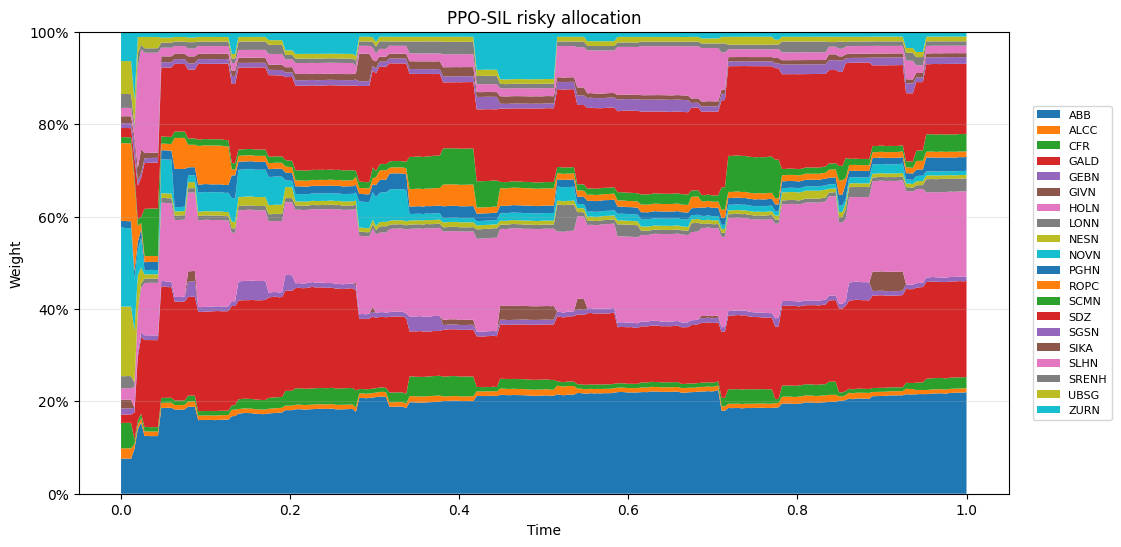

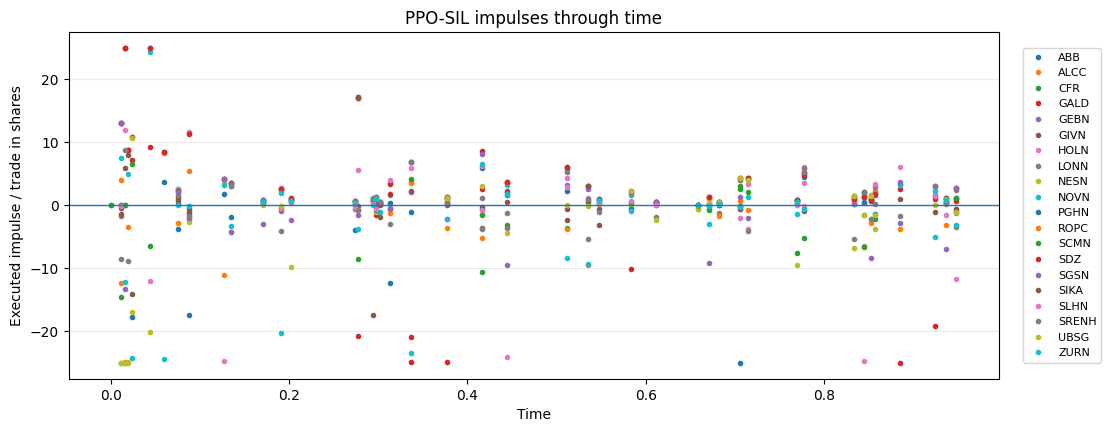

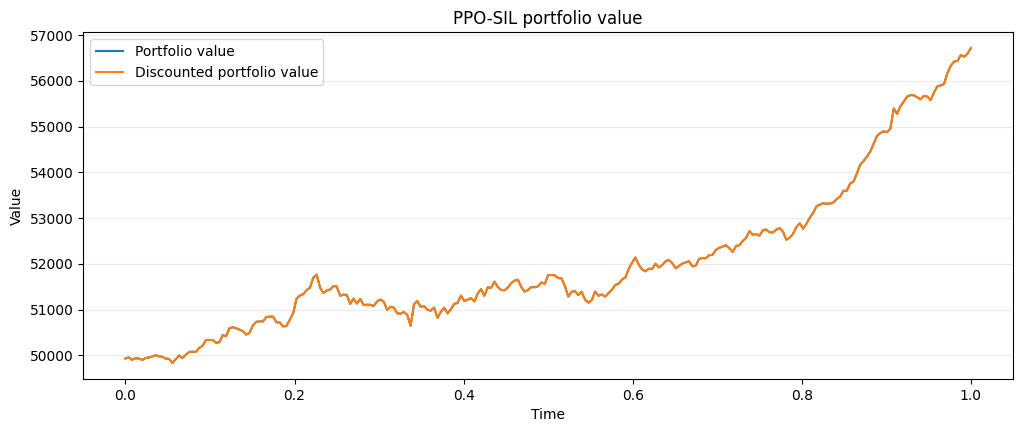


Single-path metrics:
initial_wealth: 49930.1015625
terminal_wealth: 56717.5859375
discounted_terminal_wealth: 56717.5859375
terminal_return: 0.13593972699021584
discounted_terminal_return: 0.13593972699021584
total_cost: 258.18074548245477
trade_count: 44
mean_abs_trade: 0.45870879800984293
realized_sharpe_ratio: 4.121452999068426
realized_discounted_sharpe_ratio: 4.121452999068426


In [10]:
# ---------------------------------------------------------------------
# One-path evaluation and requested visualisations
# ---------------------------------------------------------------------
single_eval = evaluate_and_plot_single_path(
    agent,
    env,
    deterministic=False,
    asset_names=asset_names,
    include_cash_in_allocation=False,   # False gives the screenshot-style risky-asset allocation
    save_dir=None,                      # e.g. 'figures' to save PNGs
    show=True,
)

single_trace = single_eval['trace']
single_metrics = single_eval['metrics']

print('\nSingle-path metrics:')
for k, v in single_metrics.items():
    print(f'{k}: {v}')

Pathwise comparison metrics:


,PPO-SIL,Buy-and-hold,PPO-SIL - Buy-and-hold
initial_wealth,49930.101562,49930.100833,0.000729
terminal_wealth,53265.773438,51202.863380,2062.910058
discounted_terminal_wealth,53265.773438,51202.863380,2062.910058
terminal_return,0.066807,0.025491,0.041316
discounted_terminal_return,0.066807,0.025491,0.041316
total_cost,193.280927,0.000000,193.280927
trade_count,43.000000,0.000000,43.000000
mean_abs_trade,0.324628,0.000000,0.324628
realized_sharpe_ratio,1.915330,1.150803,0.764527
realized_discounted_sharpe_ratio,1.915330,1.150803,0.764527


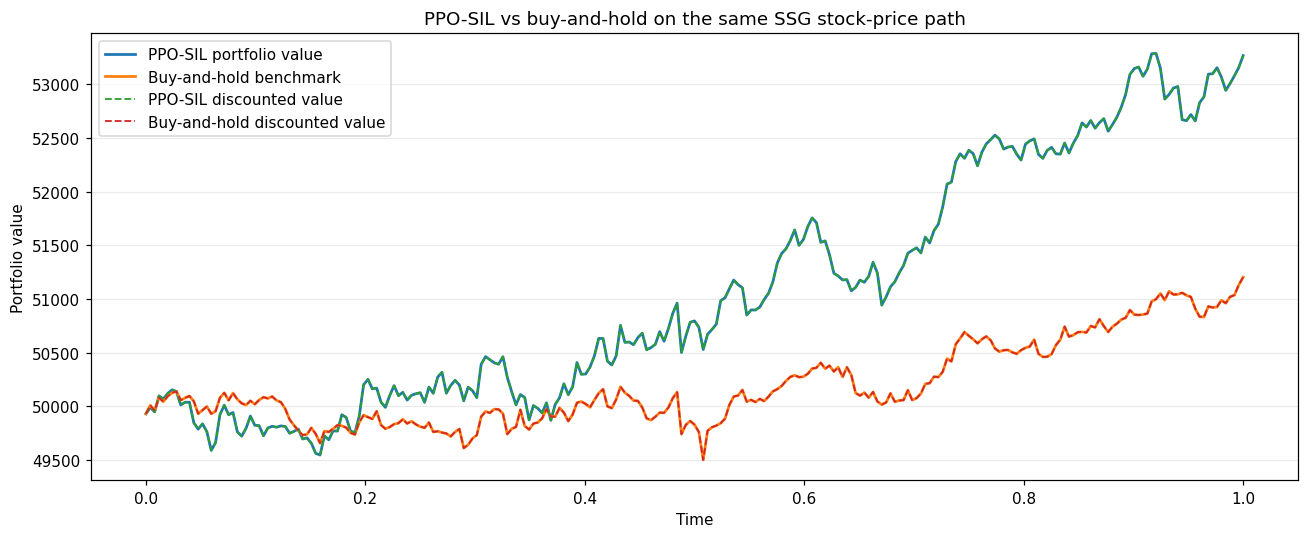

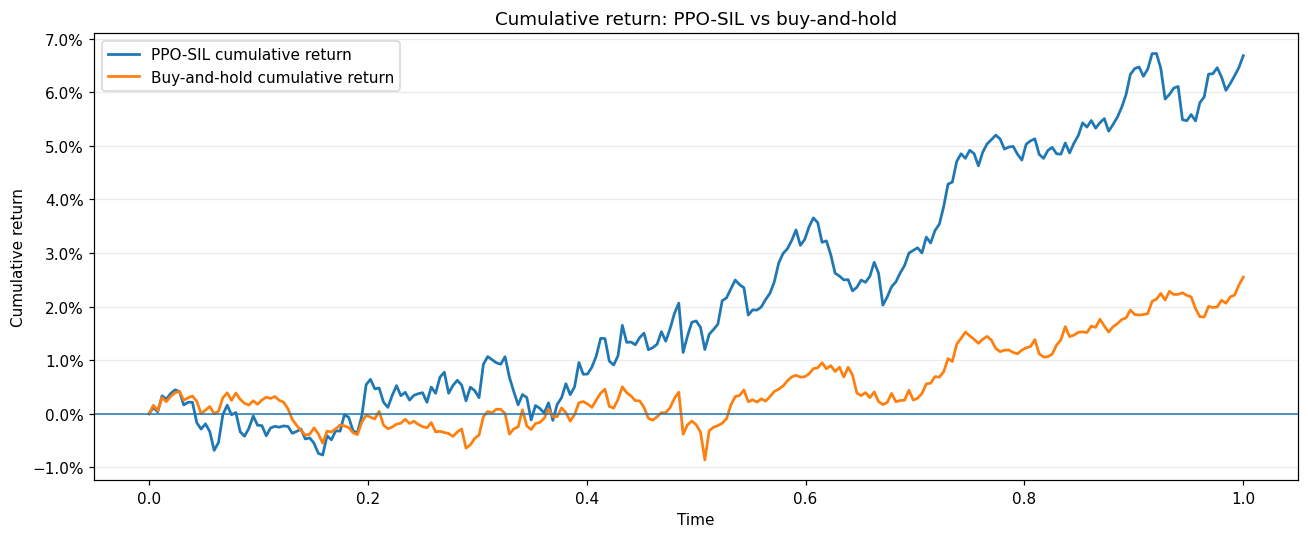

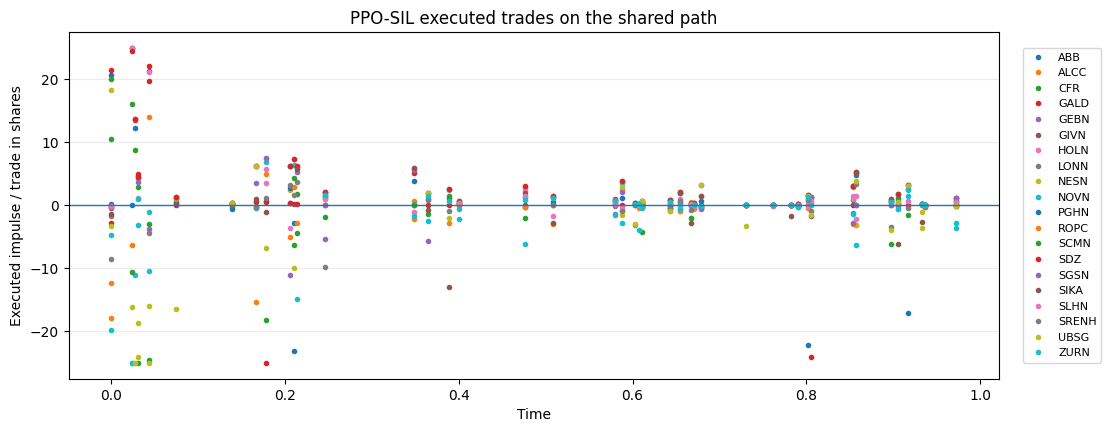

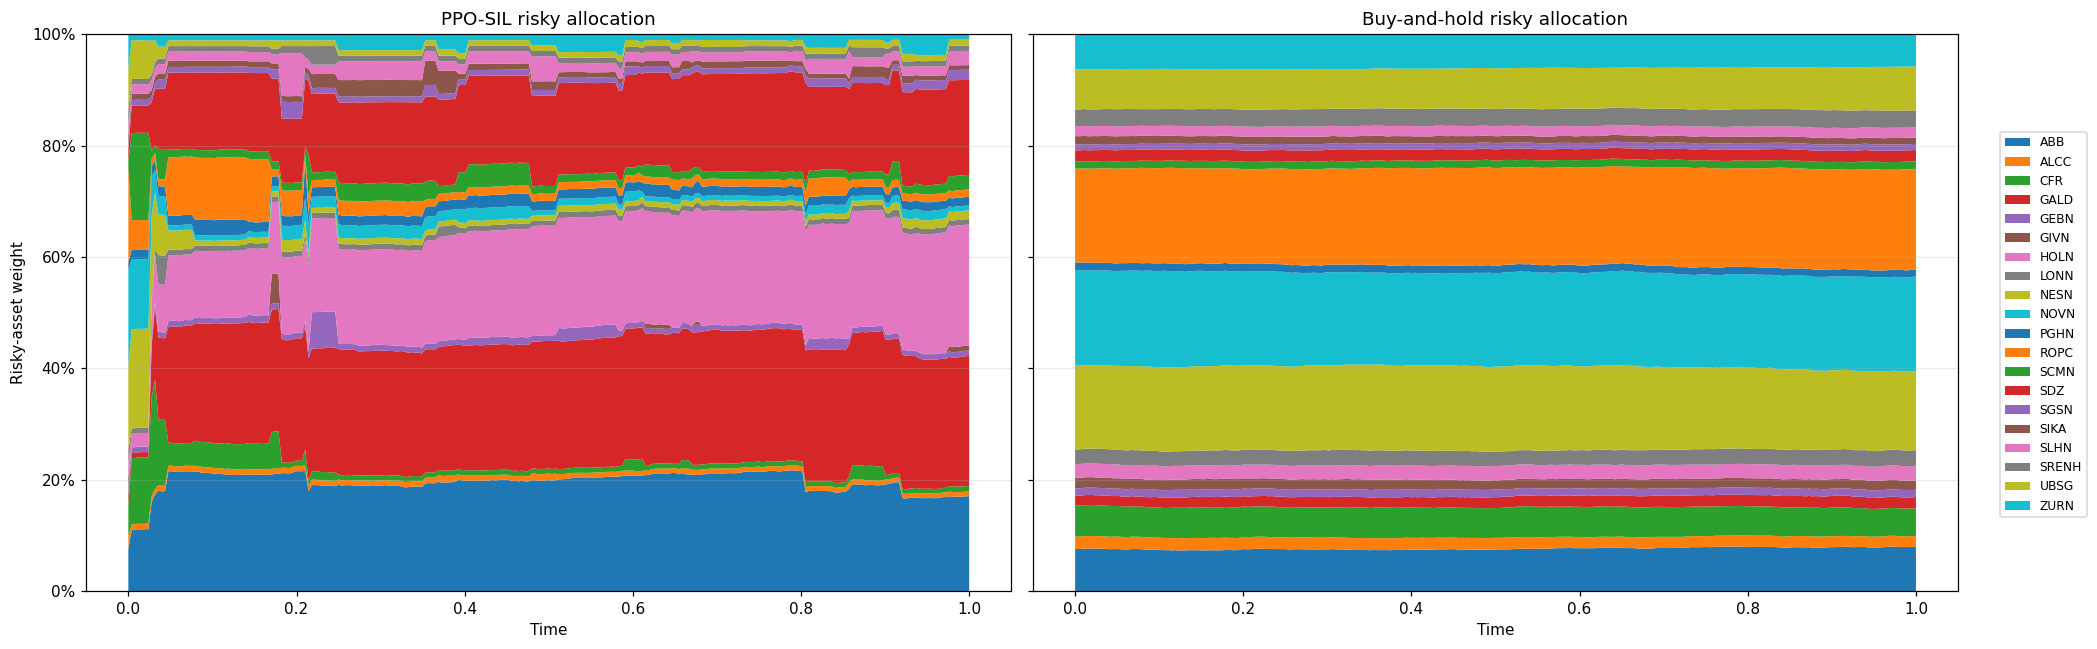

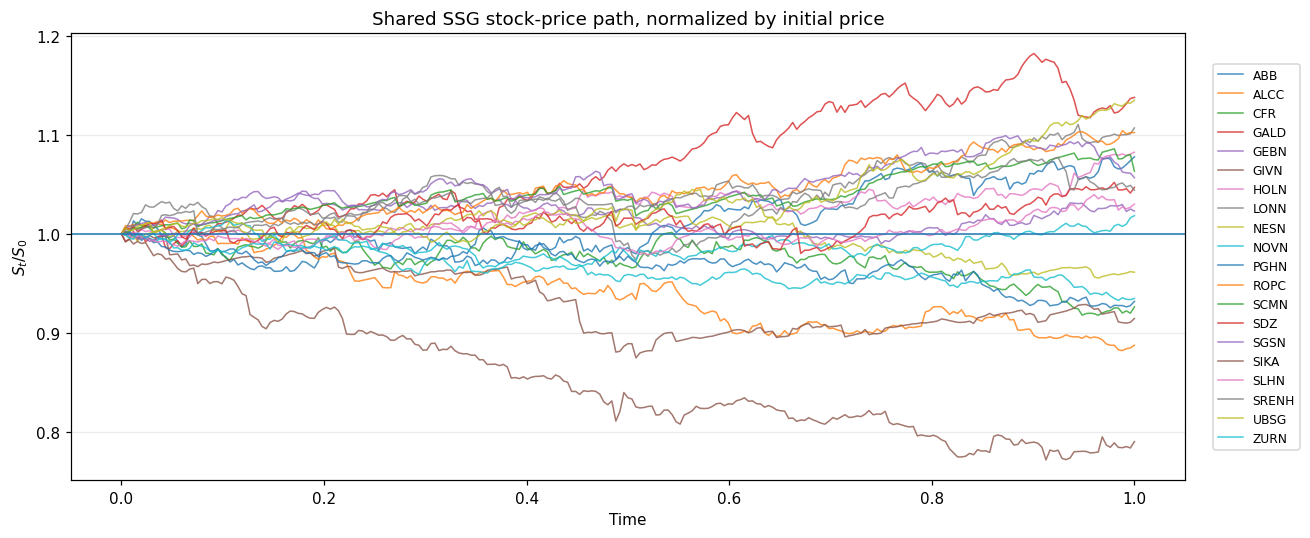

{'ppo_trace': {'asset_names': ['ABB',
   'ALCC',
   'CFR',
   'GALD',
   'GEBN',
   'GIVN',
   'HOLN',
   'LONN',
   'NESN',
   'NOVN',
   'PGHN',
   'ROPC',
   'SCMN',
   'SDZ',
   'SGSN',
   'SIKA',
   'SLHN',
   'SRENH',
   'UBSG',
   'ZURN'],
  'time': array([0.        , 0.00396825, 0.00793651, 0.01190476, 0.01587302,
         0.01984127, 0.02380952, 0.02777778, 0.03174603, 0.03571429,
         0.03968254, 0.04365079, 0.04761905, 0.0515873 , 0.05555556,
         0.05952381, 0.06349206, 0.06746032, 0.07142857, 0.07539683,
         0.07936508, 0.08333333, 0.08730159, 0.09126984, 0.0952381 ,
         0.09920635, 0.1031746 , 0.10714286, 0.11111111, 0.11507937,
         0.11904762, 0.12301587, 0.12698413, 0.13095238, 0.13492063,
         0.13888889, 0.14285714, 0.1468254 , 0.15079365, 0.1547619 ,
         0.15873016, 0.16269841, 0.16666667, 0.17063492, 0.17460317,
         0.17857143, 0.18253968, 0.18650794, 0.19047619, 0.19444444,
         0.1984127 , 0.20238095, 0.20634921, 0.21031746

In [11]:
# ============================================================
# Pathwise comparison:
# PPO-SIL portfolio policy vs passive buy-and-hold benchmark
# ============================================================

import os
import sys
import importlib
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter


# ---------------------------------------------------------------------
# Import PPO-SIL portfolio visual/evaluation utilities
# ---------------------------------------------------------------------
MODULE_DIR = Path(".").resolve()

if not (MODULE_DIR / "PPO_SIL_pfolio_mps_visuals.py").exists():
    if Path("/mnt/data/PPO_SIL_pfolio_mps_visuals.py").exists():
        MODULE_DIR = Path("/mnt/data")

if str(MODULE_DIR) not in sys.path:
    sys.path.insert(0, str(MODULE_DIR))

import PPO_SIL_pfolio_mps_visuals as PPO_VIS
PPO_VIS = importlib.reload(PPO_VIS)

from PPO_SIL_pfolio_mps_visuals import (
    evaluate_single_path,
    plot_impulses,
)


# ---------------------------------------------------------------------
# Get trained agent and environment
# ---------------------------------------------------------------------
# Assumes you already trained:
#     result = train_ppo_sil(market, cfg)
#
# Or already loaded:
#     loaded = load_ppo_sil(...)
#     agent = loaded["agent"]
#     env = loaded["env"]

if "result" in globals():
    agent = result["agent"]
    env = result["env"]
else:
    # Uses existing notebook variables if already defined.
    agent = agent
    env = env

agent.eval()


# ---------------------------------------------------------------------
# Asset names for legends
# ---------------------------------------------------------------------
if "df" in globals():
    if "asset_name" in df.columns:
        asset_names = df["asset_name"].astype(str).tolist()
    elif "ticker" in df.columns:
        asset_names = df["ticker"].astype(str).tolist()
    elif "TKR" in df.columns:
        asset_names = df["TKR"].astype(str).tolist()
    else:
        asset_names = df.index.astype(str).tolist()
else:
    asset_names = [f"Asset {j}" for j in range(env.d)]

if len(asset_names) != env.d:
    raise ValueError(f"asset_names has length {len(asset_names)}, but env.d={env.d}.")


# ---------------------------------------------------------------------
# Helper functions
# ---------------------------------------------------------------------
def safe_divide_np(numerator, denominator, eps=1.0e-12):
    numerator = np.asarray(numerator, dtype=float)
    denominator = np.asarray(denominator, dtype=float)
    out = np.zeros(np.broadcast_shapes(numerator.shape, denominator.shape), dtype=float)
    return np.divide(
        numerator,
        denominator,
        out=out,
        where=np.abs(denominator) > float(eps),
    )


def safe_sharpe_from_returns(
    returns,
    *,
    risk_free_return=0.0,
    annualization_factor=1.0,
    eps=1.0e-12,
):
    r = np.asarray(returns, dtype=float).reshape(-1)
    r = r[np.isfinite(r)]

    if r.size < 2:
        return float("nan")

    excess = r - float(risk_free_return)
    std = float(np.std(excess, ddof=0))

    if not np.isfinite(std) or std <= float(eps):
        return float("nan")

    return float(np.sqrt(float(annualization_factor)) * np.mean(excess) / std)


def make_buy_and_hold_trace_from_ppo_trace(ppo_trace, env):
    """
    Passive buy-and-hold benchmark on the exact same realised stock-price path.

    Convention:
        - Starts from the PPO-SIL initial holdings and cash.
        - Makes no trades after t=0.
        - Does not charge transaction costs because the initial portfolio is treated
          as the given starting portfolio, exactly as in the PPO environment.
        - Cash is kept constant, matching the current environment implementation.
    """
    time = np.asarray(ppo_trace["time"], dtype=float)
    prices = np.asarray(ppo_trace["prices"], dtype=float)

    h0 = np.asarray(ppo_trace["holdings"][0], dtype=float)
    cash0 = float(np.asarray(ppo_trace["cash"], dtype=float)[0])

    holdings = np.repeat(h0[None, :], len(time), axis=0)
    cash = np.full(len(time), cash0, dtype=float)

    asset_values = holdings * prices
    risky_value = asset_values.sum(axis=1)
    wealth = cash + risky_value

    discounted_wealth = np.exp(-float(env.cfg.r) * time) * wealth

    risky_weights = safe_divide_np(asset_values, risky_value[:, None])
    portfolio_weights = safe_divide_np(asset_values, wealth[:, None])
    cash_weight = safe_divide_np(cash, wealth)

    step_returns = safe_divide_np(wealth[1:], wealth[:-1]) - 1.0
    discounted_step_returns = safe_divide_np(discounted_wealth[1:], discounted_wealth[:-1]) - 1.0

    dt = float(env.dt)
    risk_free_step_return = np.exp(float(env.cfg.r) * dt) - 1.0

    metrics = {
        "initial_wealth": float(wealth[0]),
        "terminal_wealth": float(wealth[-1]),
        "discounted_terminal_wealth": float(discounted_wealth[-1]),
        "terminal_return": float(wealth[-1] / max(wealth[0], 1.0e-12) - 1.0),
        "discounted_terminal_return": float(discounted_wealth[-1] / max(wealth[0], 1.0e-12) - 1.0),
        "total_cost": 0.0,
        "trade_count": 0,
        "mean_abs_trade": 0.0,
        "realized_sharpe_ratio": safe_sharpe_from_returns(
            step_returns,
            risk_free_return=risk_free_step_return,
            annualization_factor=1.0 / max(dt, 1.0e-12),
        ),
        "realized_discounted_sharpe_ratio": safe_sharpe_from_returns(
            discounted_step_returns,
            annualization_factor=1.0 / max(dt, 1.0e-12),
        ),
    }

    return {
        "asset_names": list(ppo_trace.get("asset_names", asset_names)),
        "time": time,
        "trade_time": time[:-1],
        "prices": prices,
        "holdings": holdings,
        "cash": cash,
        "wealth": wealth,
        "discounted_wealth": discounted_wealth,
        "asset_values": asset_values,
        "risky_value": risky_value,
        "risky_weights": risky_weights,
        "portfolio_weights": portfolio_weights,
        "cash_weight": cash_weight,
        "safe_trade": np.zeros((len(time) - 1, prices.shape[1]), dtype=float),
        "step_returns": step_returns,
        "discounted_step_returns": discounted_step_returns,
        "metrics": metrics,
    }


# ---------------------------------------------------------------------
# Generate ONE shared SSG stock-price path
# ---------------------------------------------------------------------
# This is the crucial pathwise-comparison step.
# Both PPO-SIL and buy-and-hold will use this same realised price path.
with torch.no_grad():
    shared_price_path = env.sample_price_paths(1)


# ---------------------------------------------------------------------
# Evaluate PPO-SIL on that one path
# ---------------------------------------------------------------------
PPO_DETERMINISTIC = False   # Change to False to compare a stochastic PPO-SIL policy.

ppo_trace = evaluate_single_path(
    agent,
    env,
    deterministic=PPO_DETERMINISTIC,
    price_paths=shared_price_path,
    asset_names=asset_names,
)

ppo_metrics = ppo_trace["metrics"]


# ---------------------------------------------------------------------
# Compute passive buy-and-hold benchmark on the same realised path
# ---------------------------------------------------------------------
buy_hold_trace = make_buy_and_hold_trace_from_ppo_trace(ppo_trace, env)
buy_hold_metrics = buy_hold_trace["metrics"]


# ---------------------------------------------------------------------
# Metrics table
# ---------------------------------------------------------------------
metric_order = [
    "initial_wealth",
    "terminal_wealth",
    "discounted_terminal_wealth",
    "terminal_return",
    "discounted_terminal_return",
    "total_cost",
    "trade_count",
    "mean_abs_trade",
    "realized_sharpe_ratio",
    "realized_discounted_sharpe_ratio",
]

comparison_df = pd.DataFrame(
    {
        "PPO-SIL": [ppo_metrics.get(k, np.nan) for k in metric_order],
        "Buy-and-hold": [buy_hold_metrics.get(k, np.nan) for k in metric_order],
    },
    index=metric_order,
)

comparison_df["PPO-SIL - Buy-and-hold"] = comparison_df["PPO-SIL"] - comparison_df["Buy-and-hold"]

print("Pathwise comparison metrics:")
display(comparison_df)


# ---------------------------------------------------------------------
# Plot 1: portfolio value on the same path
# ---------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 5), dpi=110)

ax.plot(
    ppo_trace["time"],
    ppo_trace["wealth"],
    linewidth=1.8,
    label="PPO-SIL portfolio value",
)

ax.plot(
    buy_hold_trace["time"],
    buy_hold_trace["wealth"],
    linewidth=1.8,
    label="Buy-and-hold benchmark",
)

ax.plot(
    ppo_trace["time"],
    ppo_trace["discounted_wealth"],
    "--",
    linewidth=1.2,
    label="PPO-SIL discounted value",
)

ax.plot(
    buy_hold_trace["time"],
    buy_hold_trace["discounted_wealth"],
    "--",
    linewidth=1.2,
    label="Buy-and-hold discounted value",
)

ax.set_title("PPO-SIL vs buy-and-hold on the same SSG stock-price path")
ax.set_xlabel("Time")
ax.set_ylabel("Portfolio value")
ax.grid(True, axis="y", alpha=0.25)
ax.legend(loc="best")

plt.tight_layout()
plt.show()


# ---------------------------------------------------------------------
# Plot 2: relative performance
# ---------------------------------------------------------------------
ppo_rel = np.asarray(ppo_trace["wealth"], dtype=float) / max(float(ppo_trace["wealth"][0]), 1.0e-12) - 1.0
bh_rel = np.asarray(buy_hold_trace["wealth"], dtype=float) / max(float(buy_hold_trace["wealth"][0]), 1.0e-12) - 1.0

fig, ax = plt.subplots(figsize=(12, 5), dpi=110)

ax.plot(
    ppo_trace["time"],
    ppo_rel,
    linewidth=1.8,
    label="PPO-SIL cumulative return",
)

ax.plot(
    buy_hold_trace["time"],
    bh_rel,
    linewidth=1.8,
    label="Buy-and-hold cumulative return",
)

ax.axhline(0.0, linewidth=1.0)
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_title("Cumulative return: PPO-SIL vs buy-and-hold")
ax.set_xlabel("Time")
ax.set_ylabel("Cumulative return")
ax.grid(True, axis="y", alpha=0.25)
ax.legend(loc="best")

plt.tight_layout()
plt.show()


# ---------------------------------------------------------------------
# Plot 3: PPO-SIL trades / impulses
# ---------------------------------------------------------------------
plot_impulses(
    ppo_trace,
    asset_names=asset_names,
    title="PPO-SIL executed trades on the shared path",
)

plt.show()


# ---------------------------------------------------------------------
# Plot 4: risky allocation comparison
# ---------------------------------------------------------------------
fig, axs = plt.subplots(1, 2, figsize=(18, 6), dpi=110, sharey=True)

axs[0].stackplot(
    ppo_trace["time"],
    np.asarray(ppo_trace["risky_weights"], dtype=float).T,
    labels=asset_names,
)
axs[0].set_title("PPO-SIL risky allocation")
axs[0].set_xlabel("Time")
axs[0].set_ylabel("Risky-asset weight")
axs[0].set_ylim(0.0, 1.0)
axs[0].yaxis.set_major_formatter(PercentFormatter(1.0))
axs[0].grid(True, axis="y", alpha=0.25)

axs[1].stackplot(
    buy_hold_trace["time"],
    np.asarray(buy_hold_trace["risky_weights"], dtype=float).T,
    labels=asset_names,
)
axs[1].set_title("Buy-and-hold risky allocation")
axs[1].set_xlabel("Time")
axs[1].set_ylim(0.0, 1.0)
axs[1].yaxis.set_major_formatter(PercentFormatter(1.0))
axs[1].grid(True, axis="y", alpha=0.25)

# Single legend for both subplots.
handles, labels = axs[1].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="center left",
    bbox_to_anchor=(1.01, 0.5),
    fontsize=8,
)

plt.tight_layout()
plt.show()


# ---------------------------------------------------------------------
# Plot 5: underlying stock path used by both strategies
# ---------------------------------------------------------------------
prices = np.asarray(ppo_trace["prices"], dtype=float)
normalized_prices = prices / prices[0:1, :]

fig, ax = plt.subplots(figsize=(12, 5), dpi=110)

for j, name in enumerate(asset_names):
    ax.plot(
        ppo_trace["time"],
        normalized_prices[:, j],
        linewidth=1.0,
        alpha=0.8,
        label=name,
    )

ax.axhline(1.0, linewidth=1.0)
ax.set_title("Shared SSG stock-price path, normalized by initial price")
ax.set_xlabel("Time")
ax.set_ylabel(r"$S_t / S_0$")
ax.grid(True, axis="y", alpha=0.25)
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=8)

plt.tight_layout()
plt.show()


# ---------------------------------------------------------------------
# Optional objects for later analysis
# ---------------------------------------------------------------------
pathwise_comparison = {
    "ppo_trace": ppo_trace,
    "buy_hold_trace": buy_hold_trace,
    "comparison_df": comparison_df,
    "shared_price_path": shared_price_path,
}

pathwise_comparison

In [12]:
pathwise_comparison['ppo_trace']['portfolio_weights'][-1]*100

array([17.0583567 ,  0.82643957,  1.00547762, 23.32432706,  0.96685571,
        0.92406799, 21.68584112,  0.98563087,  1.55714945,  0.89324436,
        1.54559993,  1.32468234,  2.58874569, 17.10441678,  1.81078607,
        0.83610184,  2.55704867,  0.93664882,  1.08073023,  0.98785395])